In [114]:
library(ape)
library(castor)
library(data.table)
library(ggplot2)
library(ggpubr)
library(PATH)
library(expm)
library(ggplot2)
library(ggtree)
library(ggtreeExtra)
library(tidytree)
library(Matrix)
library(patchwork)

options(digits = 2)
library(ComplexHeatmap)
library(grid)
library(viridis)

library(markovchain)
library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)


# 1. by harmony cluster（1_20_0.2）

In [ ]:
###############################################
## organ
###############################################
cols= c('0'="#00A087FF",'1'="#4DBBD5FF",'2'="#91D1C2FF",'3'="#FF6A6A",'4'="#F39B7FFF",'5'="#8491B4FF",
            '6'="#FF8C00",'7'="#DC0000FF",'8'="#7E6148FF",'9'="#B09C85FF",'10'="#AB82FF",'11'="#00CD00")
OUTDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/PATH_1_20_0.5/"
if (!dir.exists(OUTDIR)){dir.create(OUTDIR)}
sc <- read.delim("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step5.scdata_metadata_nod_1_20_0.2.txt",header = T)
sc$organ <- sapply(strsplit(sc$sampleIDnew,"_"),"[",2)
metgroup <- read.delim("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byType/step7.nod_row_annotation_data.txt",header=T)
metgroup$mouse <- sapply(strsplit(row.names(metgroup),"_"),"[",1)
metgroup$mouse <- paste0("C",metgroup$mouse)
metgroup$clone <- sapply(strsplit(row.names(metgroup),"_"),"[",2)
# metgroup <- metgroup[metgroup$MetType=="Multi-organed",]

# pdf(file =paste0("/syn2/zhaolian/3.JiLab/results/figures/PATH_harmony_cluster_Pt.pdf"),width =5,height = 4,onefile = TRUE)
for(my.clone in 1:nrow(metgroup)){
    my.file=list.files(path = paste0("/syn2/zhaolian/3.JiLab/results/3.PacBio/4.clones_filtered/", 
                                 metgroup[my.clone,]$mouse), 
                    pattern = paste0("Clone", metgroup[my.clone,]$clone, "_.*_rescale.nwk"), 
                    full.names = TRUE)
    outname=paste0(my.clone,"_",strsplit(metgroup[my.clone,]$MetGroup,":")[[1]][1],":",metgroup[my.clone,]$mouse,":",metgroup[my.clone,]$clone)
    if(length(my.file)==1){
        # print(my.clone)
        tree <- read.tree(my.file[1])
        tree <- root(tree, outgroup = "ref", resolve.root = TRUE)
        tree <- drop.tip(tree,"ref")
        tree$states <- sc$harmony_cluster[match(tree$tip.label, sc$cellID)]
        ##############################################
        ## filter small clusters
        df <- as.data.frame(table(tree$states))
        df$ratio <- df$Freq / sum(df$Freq)
        df <- df[df$ratio>0.05,]
        clusters <- as.character(df[df$ratio>0.05,'Var1'])
        tree <- drop.tip(tree,tree$tip.label[!tree$states %in% clusters])
        tree$states <- sc$harmony_cluster[match(tree$tip.label, sc$cellID)]
        ## filter end
        ##############################################
        samplesAll <- as.character(c(0:16))
        samples <- samplesAll[samplesAll %in% tree$states]
        tree$states <- factor(tree$states, levels=samples)
        # tree$edge.length <- rep(1,length(tree$edge.length))
        # mycol=cols[clusters]
        if (length(unique(as.character(tree$states)))!=1){
            message("\t",outname)
            Pinf <- PATH_inf(tree = tree, cell_states = "states", nstates = length(unique(tree$states)))
            Pinf$Pt[is.na(Pinf$Pt)] <- 0
            Pinf$P[is.na(Pinf$P)] <- 0

            row.names(Pinf$P) <- row.names(Pinf$Pt)
            colnames(Pinf$P) <- colnames(Pinf$Pt)
            
            write.table(Pinf$Pt,file=paste0(OUTDIR,"Pt_",
                                            metgroup[my.clone,]$MetType,"_",
                                            strsplit(metgroup[my.clone,]$MetGroup,":")[[1]][1],"_",
                                            metgroup[my.clone,]$mouse,"_",
                                            metgroup[my.clone,]$clone,".txt"))
            write.table(Pinf$P,file=paste0(OUTDIR,"P_",
                                            metgroup[my.clone,]$MetType,"_",
                                            strsplit(metgroup[my.clone,]$MetGroup,":")[[1]][1],"_",
                                            metgroup[my.clone,]$mouse,"_",
                                            metgroup[my.clone,]$clone,".txt"))
            write.table(df,file=paste0(OUTDIR,
                                            metgroup[my.clone,]$MetType,"_",
                                            strsplit(metgroup[my.clone,]$MetGroup,":")[[1]][1],"_",
                                            metgroup[my.clone,]$mouse,"_",
                                            metgroup[my.clone,]$clone,"_cellNum.txt"))
        }
    }
}
# dev.off()




	5_MetGroup1:C4011:14

	6_MetGroup1:C4011:18

	8_MetGroup1:C4011:22

	10_MetGroup1:C4011:33

	11_MetGroup1:C4011:34

	12_MetGroup1:C4011:38

	13_MetGroup1:C4011:45

	14_MetGroup1:C4011:46

	15_MetGroup1:C4011:47

	16_MetGroup1:C4011:48

	17_MetGroup1:C4011:50

	18_MetGroup1:C4011:54

	22_MetGroup1:C4011:64

	24_MetGroup1:C4011:68

	32_MetGroup1:C4011:85

	39_MetGroup1:C4033:21

	40_MetGroup1:C4033:22

	41_MetGroup1:C4033:23

	43_MetGroup1:C4033:30

	44_MetGroup1:C4033:33

	45_MetGroup1:C4033:36

	46_MetGroup1:C4033:37

	47_MetGroup1:C4033:38

	61_MetGroup1:C4033:7

	64_MetGroup1:C4011:13

	65_MetGroup1:C4011:6

	66_MetGroup1:C4033:1

	67_MetGroup1:C4011:12

	68_MetGroup1:C4011:40

	69_MetGroup1:C4011:10

	70_MetGroup1:C4033:16

	71_MetGroup1:C4011:17

	73_MetGroup1:C4007:15

	74_MetGroup1:C4033:28

	75_MetGroup1:C4033:31

	76_MetGroup1:C4011:30

	77_MetGroup1:C4007:7

	78_MetGroup1:C4011:7

	79_MetGroup1:C4007:3

	80_MetGroup1:C4007:11

	83_MetGroup1:C4007:40

	84_MetGroup1:C4033:40

	

# 2. 统计ENT & NET

In [5]:
library(ComplexHeatmap)
library(circlize)

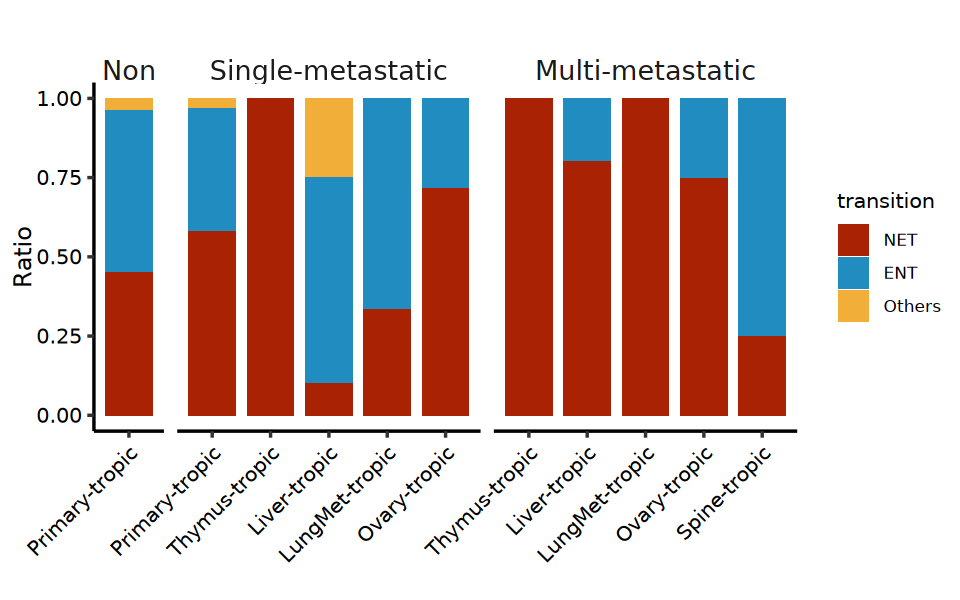

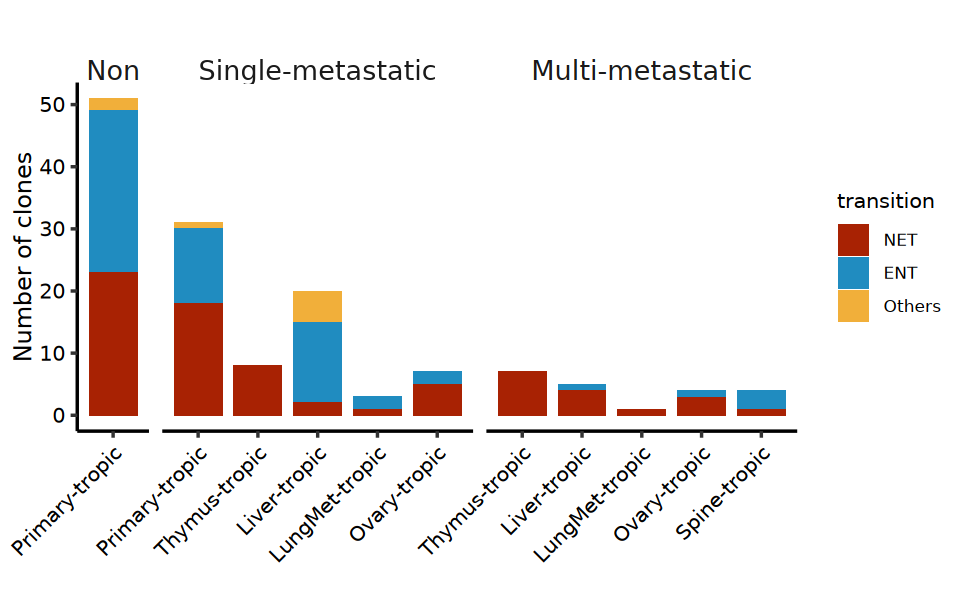

In [49]:
WORKDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/PATH_1_20_0.2/"
dt <- read.table("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/5.5.PATH/harmony_cluster_transition_type.txt",header=T)
files <- list.files(path=paste0(WORKDIR),pattern="^P_.*")
length(files)


setwd(WORKDIR)
## Neuronal clusters: 1,4,11
## Epithelial clusters: 0,10
dmatrix <- data.table()
for(my.file in files){
    temp <- read.table(my.file,sep=" ",check.names=F)
    Ns <- sum(colSums(temp)[c("1","2","5")],na.rm = TRUE)
    Es <- sum(colSums(temp)[c("0","3","7","8")],na.rm = TRUE)
    top1 <- as.numeric(colSums(temp)[which.max(colSums(temp))])
    my.file <- gsub(".txt","",my.file)
    s=strsplit(my.file,"_")[[1]]
    myclone=paste0(s[4],"_",s[5])
    myclone <- gsub("C","",myclone)
    if(Ns > Es & Ns >= top1){
        dmatrix <- rbind(dmatrix, data.frame(clone=myclone,transitionbyCutoff="ENT"))
    }else if(Es > Ns & Es >= top1){
        dmatrix <- rbind(dmatrix, data.frame(clone=myclone,transitionbyCutoff="NET"))
    }else{
        maxCluster=names(colSums(temp)[which.max(colSums(temp))])
        dmatrix <- rbind(dmatrix, data.frame(clone=myclone,transitionbyCutoff=maxCluster))
    }
}
dmatrix <- merge(dmatrix,dt,by="clone",all.x= T)
dmatrix<- dmatrix[order(ID)]
dmatrix[,num := 1]
dmatrix$transitionbyCutoff <- ifelse(dmatrix$transitionbyCutoff %in% c("NET","ENT"),dmatrix$transitionbyCutoff,"Others")
write.table(dmatrix,file="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/harmony_cluster_transition_type_byCutoff.txt",sep="\t",row.names=F, quote=F)


dmatrix <- read.delim("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/harmony_cluster_transition_type_byCutoff.txt")
dmatrix$transitionbyCutoff <- factor(dmatrix$transitionbyCutoff, levels=rev(c("NET","ENT","Others")))
dmatrix$MetStatus <- gsub("Non-metastatic","Non",dmatrix$MetStatus)
dmatrix$MetStatus <- factor(dmatrix$MetStatus,levels=c('Non','Single-metastatic','Multi-metastatic'))
dmatrix$MetGroup <- gsub("MetGroup[0-9]:","",dmatrix$MetGroup)
dmatrix$MetGroup <- factor(dmatrix$MetGroup,levels=c('Primary-tropic','Thymus-tropic','Liver-tropic','LungMet-tropic','Ovary-tropic','Spine-tropic'))
# mycols=c("#E64B35FF","#4DBBD5FF","#00A087FF","#3C5488FF","#F39B7FFF","#8491B4FF")
mycols=c("#A82203FF","#208CC0FF","#F1AF3AFF","#CF5E4EFF","#637B31FF","#003967FF")[1:length(unique(dmatrix$transitionbyCutoff))]
p1 <- ggplot(dmatrix, aes(x=MetGroup, y=num, fill=transitionbyCutoff)) +
    geom_bar(stat = "identity", width=0.8,position="fill")+theme_classic(base_size = 16) +
    facet_grid(.~MetStatus, scale="free_x",space="free_x")+
    labs(y="Ratio",x="")+
    ggtitle("")+
    scale_fill_manual(values=rev(mycols))+
    theme(axis.text.x = element_text(size=12, colour = "black", angle=45, vjust=1, hjust=1),#, angle=90, vjust=0.5, hjust=1
        axis.text.y = element_text(size=12, colour = "black"),
        axis.title.y = element_text(size = 14),
        strip.text = element_text(size = 16, margin = margin()),
        panel.grid =element_blank(),
        strip.background = element_blank(),    # Remove facet strip background
        legend.position="right",
        legend.title=element_text(size=12),
        legend.key.size=unit(0.7,"cm"),
        legend.text=element_text(size=10))+
        guides(fill=guide_legend(ncol=1,reverse=TRUE,title="transition"))

p2 <- ggplot(dmatrix, aes(x=MetGroup, y=num, fill=transitionbyCutoff)) +
  geom_bar(position="stack", stat="identity", width=0.8)+theme_classic(base_size = 16) +
    facet_grid(.~MetStatus, scale="free_x",space="free_x")+
    labs(y="Number of clones",x="")+
    ggtitle("")+
    scale_fill_manual(values=rev(mycols))+
    theme(axis.text.x = element_text(size=12, colour = "black", angle=45, vjust=1, hjust=1),#
        axis.text.y = element_text(size=12, colour = "black"),
        axis.title.y = element_text(size = 14),
        strip.text = element_text(size = 16, margin = margin()),
        panel.grid =element_blank(),
        strip.background = element_blank(),    # Remove facet strip background
        legend.position="right",
        legend.title=element_text(size=12),
        legend.key.size=unit(0.7,"cm"),
        legend.text=element_text(size=10))+
        guides(fill=guide_legend(ncol=1,reverse=TRUE,title="transition"))

options(repr.plot.width=8,repr.plot.height=5)
p1
p2

# 3. 统计ENT & NET，入度-出度

[1] 141

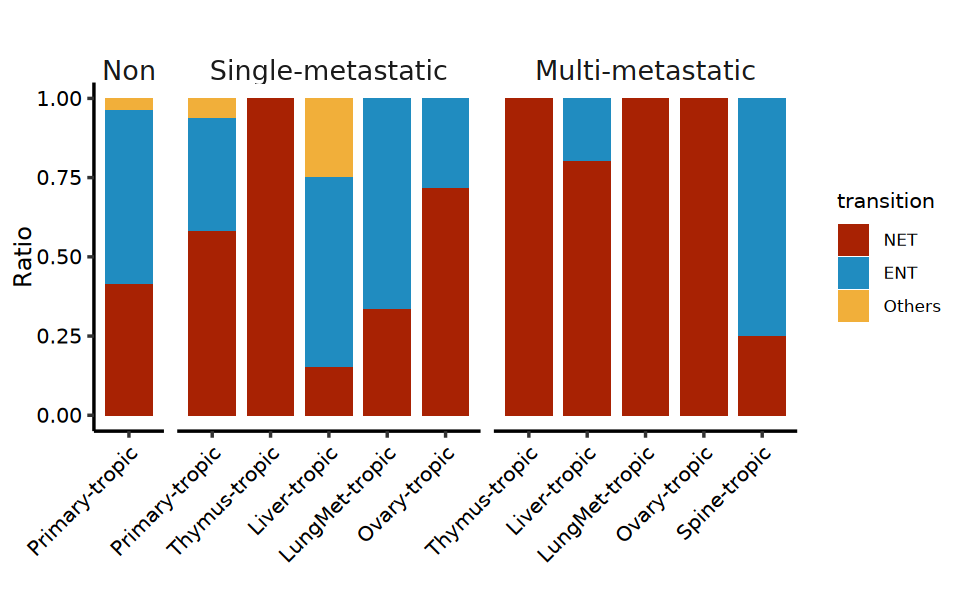

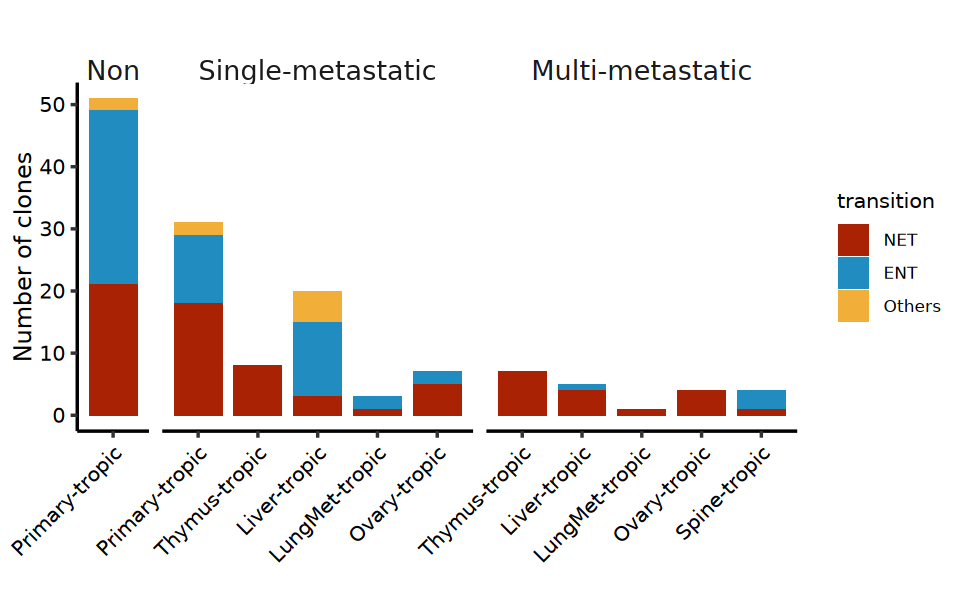

In [68]:
WORKDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/PATH_1_20_0.2/"
dt <- read.table("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/5.5.PATH/harmony_cluster_transition_type.txt",header=T)
# dt$transition = dt$transitionbyCutoff
files <- list.files(path=paste0(WORKDIR),pattern="^P_.*")
length(files)


setwd(WORKDIR)
## Neuronal clusters: 1,4,11
## Epithelial clusters: 0,10
dmatrix <- data.table()
for(my.file in files){
    temp <- read.table(my.file,sep=" ",check.names=F)
    diag(temp) <- 0
    # Ns <- sum(colSums(temp)[c("1","2","5")],na.rm = TRUE)-sum(rowSums(temp)[c("1","2","5")],na.rm = TRUE)
    # Es <- sum(colSums(temp)[c("0","3","7","8")],na.rm = TRUE)-sum(rowSums(temp)[c("0","3","7","8")],na.rm = TRUE)
    Ns <- sum(colSums(temp)[c("1","2","5")],na.rm = TRUE)
    Es <- sum(colSums(temp)[c("0","3","7","8")],na.rm = TRUE)
    others <-sum(colSums(temp)[c("4","6")],na.rm = TRUE)-sum(rowSums(temp)[c("4","6")],na.rm = TRUE)
    my.file <- gsub(".txt","",my.file)
    s=strsplit(my.file,"_")[[1]]
    myclone=paste0(s[4],"_",s[5])
    myclone <- gsub("C","",myclone)
    if(Ns > Es & Ns > others){
        dmatrix <- rbind(dmatrix, data.frame(clone=myclone,transitionbyCutoff="ENT"))
    }else if(Es > Ns & Es > others){
        dmatrix <- rbind(dmatrix, data.frame(clone=myclone,transitionbyCutoff="NET"))
    }else{
        maxCluster=names(colSums(temp)[which.max(colSums(temp))])
        dmatrix <- rbind(dmatrix, data.frame(clone=myclone,transitionbyCutoff=maxCluster))
    }
}
dmatrix <- merge(dmatrix,dt,by="clone",all.x= T)
dmatrix<- dmatrix[order(ID)]
dmatrix[,num := 1]
dmatrix$transitionbyCutoff <- ifelse(dmatrix$transitionbyCutoff %in% c("NET","ENT"),dmatrix$transitionbyCutoff,"Others")
write.table(dmatrix,file="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/harmony_cluster_transition_type_byCutoff_in-out2.txt",sep="\t",row.names=F, quote=F)


dmatrix <- read.delim("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/harmony_cluster_transition_type_byCutoff_in-out2.txt")
dmatrix$transitionbyCutoff <- factor(dmatrix$transitionbyCutoff, levels=rev(c("NET","ENT","Others")))
dmatrix$MetStatus <- gsub("Non-metastatic","Non",dmatrix$MetStatus)
dmatrix$MetStatus <- factor(dmatrix$MetStatus,levels=c('Non','Single-metastatic','Multi-metastatic'))
dmatrix$MetGroup <- gsub("MetGroup[0-9]:","",dmatrix$MetGroup)
dmatrix$MetGroup <- factor(dmatrix$MetGroup,levels=c('Primary-tropic','Thymus-tropic','Liver-tropic','LungMet-tropic','Ovary-tropic','Spine-tropic'))
# mycols=c("#E64B35FF","#4DBBD5FF","#00A087FF","#3C5488FF","#F39B7FFF","#8491B4FF")
mycols=c("#A82203FF","#208CC0FF","#F1AF3AFF","#CF5E4EFF","#637B31FF","#003967FF")[1:length(unique(dmatrix$transitionbyCutoff))]
p1 <- ggplot(dmatrix, aes(x=MetGroup, y=num, fill=transitionbyCutoff)) +
    geom_bar(stat = "identity", width=0.8,position="fill")+theme_classic(base_size = 16) +
    facet_grid(.~MetStatus, scale="free_x",space="free_x")+
    labs(y="Ratio",x="")+
    ggtitle("")+
    scale_fill_manual(values=rev(mycols))+
    theme(axis.text.x = element_text(size=12, colour = "black", angle=45, vjust=1, hjust=1),#, angle=90, vjust=0.5, hjust=1
        axis.text.y = element_text(size=12, colour = "black"),
        axis.title.y = element_text(size = 14),
        strip.text = element_text(size = 16, margin = margin()),
        panel.grid =element_blank(),
        strip.background = element_blank(),    # Remove facet strip background
        legend.position="right",
        legend.title=element_text(size=12),
        legend.key.size=unit(0.7,"cm"),
        legend.text=element_text(size=10))+
        guides(fill=guide_legend(ncol=1,reverse=TRUE,title="transition"))

p2 <- ggplot(dmatrix, aes(x=MetGroup, y=num, fill=transitionbyCutoff)) +
  geom_bar(position="stack", stat="identity", width=0.8)+theme_classic(base_size = 16) +
    facet_grid(.~MetStatus, scale="free_x",space="free_x")+
    labs(y="Number of clones",x="")+
    ggtitle("")+
    scale_fill_manual(values=rev(mycols))+
    theme(axis.text.x = element_text(size=12, colour = "black", angle=45, vjust=1, hjust=1),#
        axis.text.y = element_text(size=12, colour = "black"),
        axis.title.y = element_text(size = 14),
        strip.text = element_text(size = 16, margin = margin()),
        panel.grid =element_blank(),
        strip.background = element_blank(),    # Remove facet strip background
        legend.position="right",
        legend.title=element_text(size=12),
        legend.key.size=unit(0.7,"cm"),
        legend.text=element_text(size=10))+
        guides(fill=guide_legend(ncol=1,reverse=TRUE,title="transition"))

options(repr.plot.width=8,repr.plot.height=5)
p1
p2

In [65]:
diag(temp) <- 0
temp

,0,1,2,6
,<dbl>,<dbl>,<dbl>,<dbl>
0,0.00,0.058,0.041,0.048
1,0.55,0.000,0.000,0.000
2,0.40,0.000,0.000,0.134
6,0.44,0.000,0.126,0.000


# 4. PATH matrix heatmap

In [50]:
library(ComplexHeatmap)
library(circlize)

In [51]:
###############################################
## harmony cluster
###############################################
cols= c('0'="#00A087FF",'1'="#4DBBD5FF",'2'="#91D1C2FF",'3'="#FF6A6A",'4'="#F39B7FFF",'5'="#8491B4FF",
            '6'="#FF8C00",'7'="#DC0000FF",'8'="#7E6148FF",'9'="#B09C85FF",'10'="#AB82FF",'11'="#00CD00")
files <- list.files(path="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/PATH_1_20_0.2",
                    pattern="^P_")
files[1:5]
###############################################
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/PATH_1_20_0.2")
pdf(file =paste0("/syn2/zhaolian/3.JiLab/results/figures/PATH_harmonyCluster_heatmap_1_20_0.2.pdf"),width =4.2,height = 3.3,onefile = TRUE)
for(my.file in files){
    matrix <- read.table(my.file, check.names = FALSE)
    my.file <- gsub(".txt","",my.file)
    s=strsplit(my.file,"_")[[1]]
    myclone=paste0(s[4],"_",s[5])
    outname=gsub("C","",myclone)
    ##########################################################
    ## plot1: matrix
    ##########################################################
    plot=Heatmap(as.matrix(matrix),
            column_title = outname,
            row_names_gp = gpar(fontsize = 12, fontface = "bold"), 
            column_names_gp = gpar(fontsize = 12, fontface = "bold"),
            cluster_rows = FALSE,
            cluster_columns = FALSE,
            row_names_side = 'left',
            column_names_side = 'top',
            column_names_rot = 0,
            col = colorRamp2(
                    c(0, 0.3,0.6,1),
                    c("#fcebd5", "#f99b75", "#e0325e", "#50193BFF")
            ),
            cell_fun = function(j, i, x, y, width, height, fill) {
                grid.text(sprintf("%.2f", as.matrix(matrix)[i, j]), x, y, gp = gpar(fontsize = 12))
            },
            heatmap_legend_param = list(title = "state transitions")
    )
    grid.newpage()
    print(plot)
}
dev.off()




[1] "P_Multi-organed_MetGroup2_C4007_1.txt" 
[2] "P_Multi-organed_MetGroup2_C4007_20.txt"
[3] "P_Multi-organed_MetGroup2_C4007_37.txt"
[4] "P_Multi-organed_MetGroup2_C4007_41.txt"
[5] "P_Multi-organed_MetGroup2_C4007_44.txt"

pdf 
  2